DATA UNDERSTANDING - KUALITAS UDARA LAMONGAN

[1] INFORMASI DATA
------------------------------------------------------------
Jumlah baris : 1464
Jumlah kolom : 6

Kolom:
- valid_time
- latitude
- longitude
- pm1_ug_m3
- pm2p5_ug_m3
- pm10_ug_m3

Periode data:
Mulai : 2025-08-29 00:00:00
Selesai: 2026-08-29 18:00:00

[2] TIPE DATA
------------------------------------------------------------
valid_time     datetime64[us]
latitude              float64
longitude             float64
pm1_ug_m3             float64
pm2p5_ug_m3           float64
pm10_ug_m3            float64
dtype: object

[3] STATISTIK DESKRIPTIF
------------------------------------------------------------
         pm1_ug_m3  pm2p5_ug_m3   pm10_ug_m3
count  1464.000000  1464.000000  1464.000000
mean     57.529129    62.028295    63.610400
std      33.978961    35.869201    36.420732
min       8.039837    10.248062    10.406658
25%      29.858387    33.187166    34.235181
50%      50.123969    53.588804    54.827098
75%      7

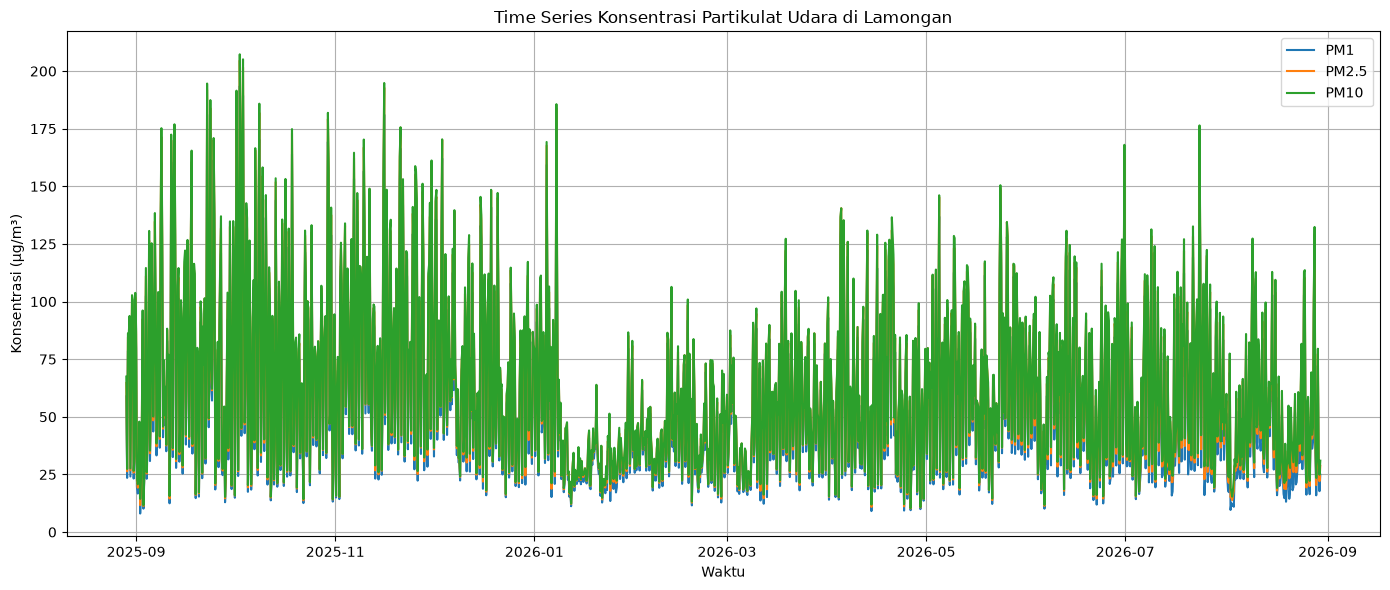


[9] RATA-RATA POLUTAN
------------------------------------------------------------
pm1_ug_m3: 57.53 µg/m³
pm2p5_ug_m3: 62.03 µg/m³
pm10_ug_m3: 63.61 µg/m³

ANALISIS SELESAI


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATA
# ============================================================

file = "../data/data_lamongan_clean.csv"

df = pd.read_csv(file)

df["valid_time"] = pd.to_datetime(df["valid_time"])

print("=" * 60)
print("DATA UNDERSTANDING - KUALITAS UDARA LAMONGAN")
print("=" * 60)

# ============================================================
# 2. INFORMASI DATA
# ============================================================

print("\n[1] INFORMASI DATA")
print("-" * 60)

print("Jumlah baris :", len(df))
print("Jumlah kolom :", len(df.columns))

print("\nKolom:")
for col in df.columns:
    print("-", col)

print("\nPeriode data:")
print("Mulai :", df["valid_time"].min())
print("Selesai:", df["valid_time"].max())

# ============================================================
# 3. TIPE DATA
# ============================================================

print("\n[2] TIPE DATA")
print("-" * 60)

print(df.dtypes)

# ============================================================
# 4. DESKRIPSI STATISTIK
# ============================================================

pollutants = [
    "pm1_ug_m3",
    "pm2p5_ug_m3",
    "pm10_ug_m3"
]

print("\n[3] STATISTIK DESKRIPTIF")
print("-" * 60)

print(df[pollutants].describe())

# ============================================================
# 5. MISSING VALUE
# ============================================================

print("\n[4] MISSING VALUE")
print("-" * 60)

print(df.isnull().sum())

# ============================================================
# 6. DUPLIKAT
# ============================================================

print("\n[5] DATA DUPLIKAT")
print("-" * 60)

print("Jumlah duplikat:", df.duplicated().sum())

print(
    "Duplikat waktu:",
    df["valid_time"].duplicated().sum()
)

# ============================================================
# 7. NILAI NEGATIF
# ============================================================

print("\n[6] NILAI NEGATIF")
print("-" * 60)

for col in pollutants:
    jumlah = (df[col] < 0).sum()
    print(f"{col}: {jumlah}")

# ============================================================
# 8. NILAI MINIMUM DAN MAKSIMUM
# ============================================================

print("\n[7] MINIMUM DAN MAKSIMUM")
print("-" * 60)

for col in pollutants:
    print(f"\n{col}")
    print("Minimum:", df[col].min())
    print("Maksimum:", df[col].max())

# ============================================================
# 9. OUTLIER MENGGUNAKAN IQR
# ============================================================

print("\n[8] DETEKSI OUTLIER")
print("-" * 60)

for col in pollutants:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"\n{col}")
    print("Batas bawah :", lower)
    print("Batas atas  :", upper)
    print("Jumlah outlier:", len(outliers))

# ============================================================
# 10. GRAFIK TIME SERIES
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    df["valid_time"],
    df["pm1_ug_m3"],
    label="PM1"
)

plt.plot(
    df["valid_time"],
    df["pm2p5_ug_m3"],
    label="PM2.5"
)

plt.plot(
    df["valid_time"],
    df["pm10_ug_m3"],
    label="PM10"
)

plt.title(
    "Time Series Konsentrasi Partikulat Udara "
    "di Lamongan"
)

plt.xlabel("Waktu")
plt.ylabel("Konsentrasi (µg/m³)")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# ============================================================
# 11. RATA-RATA POLUTAN
# ============================================================

print("\n[9] RATA-RATA POLUTAN")
print("-" * 60)

for col in pollutants:
    print(
        f"{col}: "
        f"{df[col].mean():.2f} µg/m³"
    )

print("\n" + "=" * 60)
print("ANALISIS SELESAI")
print("=" * 60)

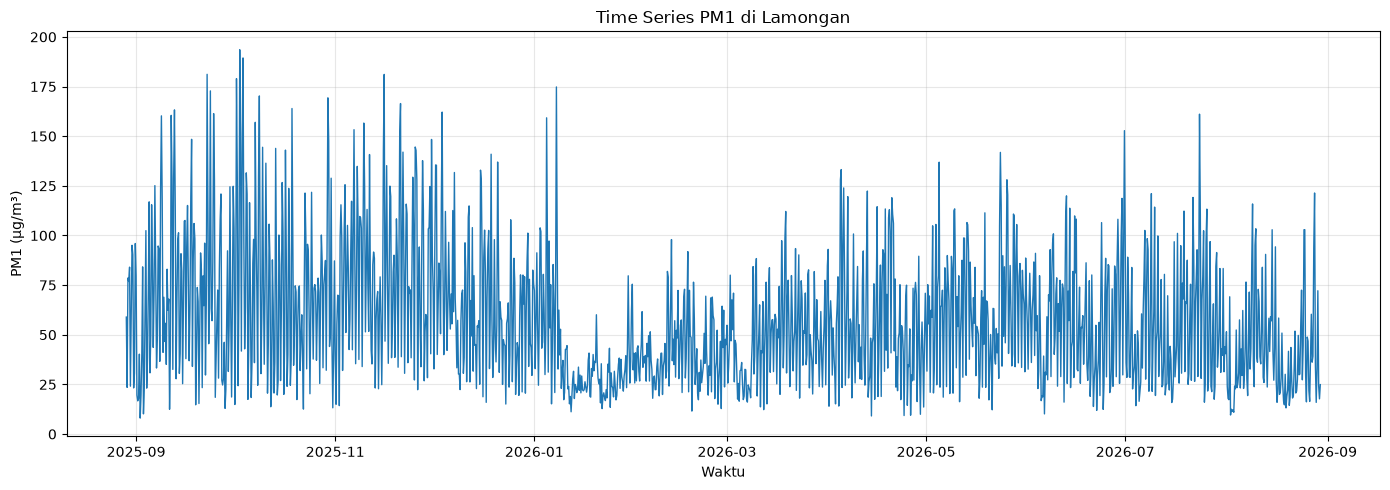

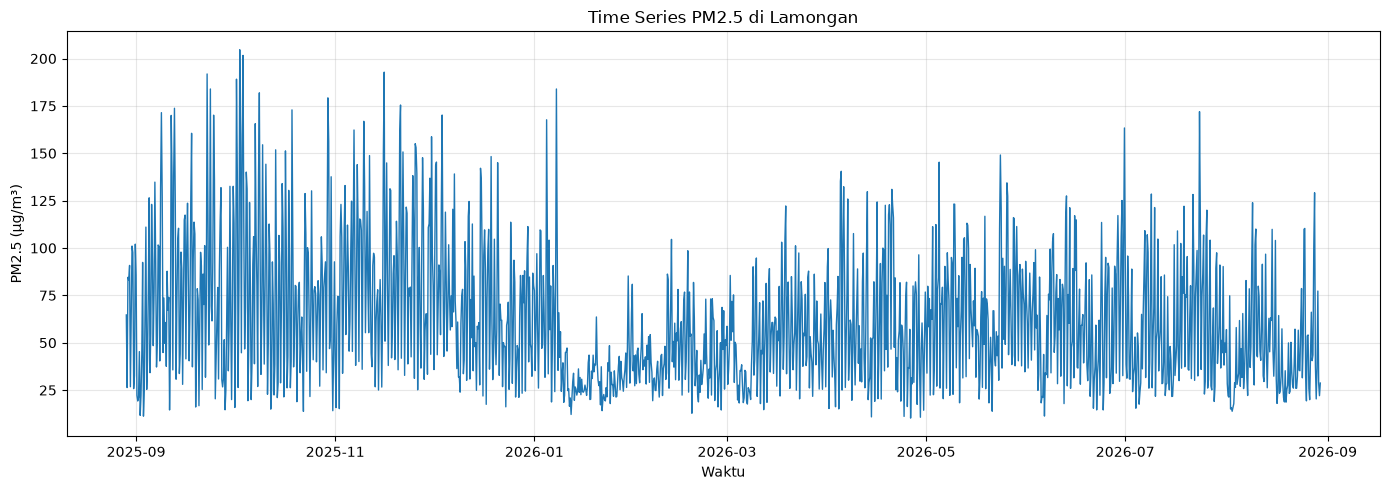

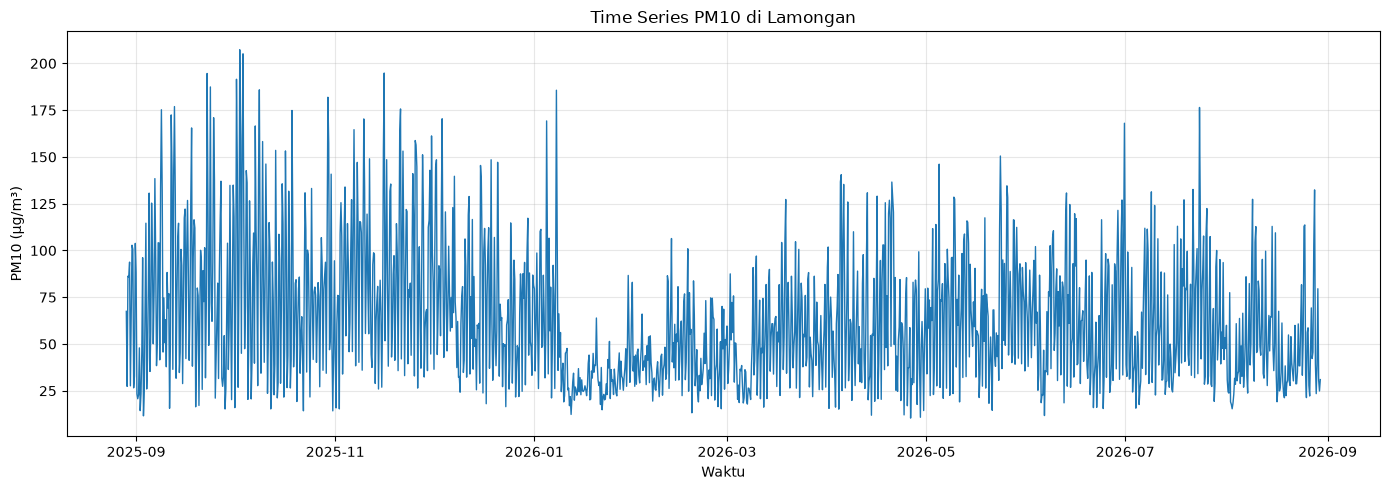

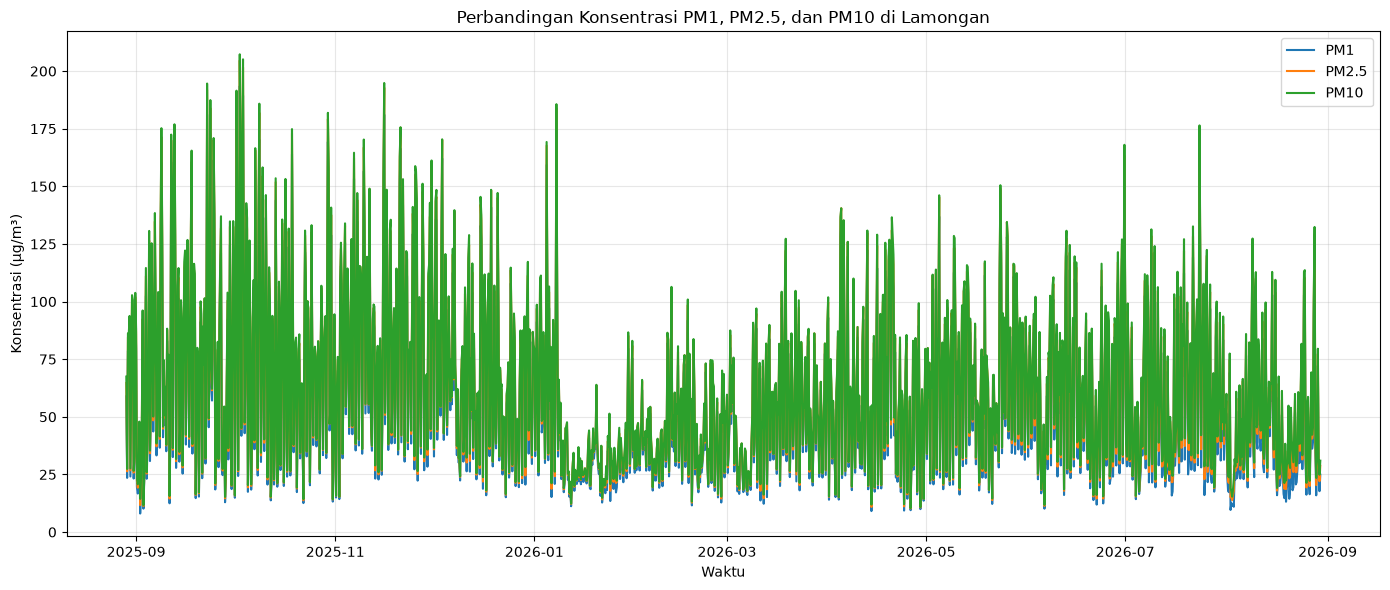

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data hasil cleaning
df = pd.read_csv("../data/data_lamongan_clean.csv")

df["valid_time"] = pd.to_datetime(df["valid_time"])

# Urutkan berdasarkan waktu
df = df.sort_values("valid_time")


# ============================================================
# TIME SERIES PM1
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["valid_time"],
    df["pm1_ug_m3"],
    linewidth=1
)

plt.title("Time Series PM1 di Lamongan")
plt.xlabel("Waktu")
plt.ylabel("PM1 (µg/m³)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# TIME SERIES PM2.5
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["valid_time"],
    df["pm2p5_ug_m3"],
    linewidth=1
)

plt.title("Time Series PM2.5 di Lamongan")
plt.xlabel("Waktu")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# TIME SERIES PM10
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["valid_time"],
    df["pm10_ug_m3"],
    linewidth=1
)

plt.title("Time Series PM10 di Lamongan")
plt.xlabel("Waktu")
plt.ylabel("PM10 (µg/m³)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# PERBANDINGAN SEMUA POLUTAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    df["valid_time"],
    df["pm1_ug_m3"],
    label="PM1"
)

plt.plot(
    df["valid_time"],
    df["pm2p5_ug_m3"],
    label="PM2.5"
)

plt.plot(
    df["valid_time"],
    df["pm10_ug_m3"],
    label="PM10"
)

plt.title("Perbandingan Konsentrasi PM1, PM2.5, dan PM10 di Lamongan")
plt.xlabel("Waktu")
plt.ylabel("Konsentrasi (µg/m³)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cek missing value

In [3]:
# ============================================================
# [3] CEK MISSING VALUE
# ============================================================

print("\n[3] MISSING VALUE")
print("-" * 60)

missing = df.isnull().sum()

print(missing)

print("\nPersentase missing value:")
print((df.isnull().mean() * 100).round(2))


[3] MISSING VALUE
------------------------------------------------------------
valid_time     0
latitude       0
longitude      0
pm1_ug_m3      0
pm2p5_ug_m3    0
pm10_ug_m3     0
dtype: int64

Persentase missing value:
valid_time     0.0
latitude       0.0
longitude      0.0
pm1_ug_m3      0.0
pm2p5_ug_m3    0.0
pm10_ug_m3     0.0
dtype: float64


Cek nilai negatif

In [4]:
# ============================================================
# [4] CEK NILAI NEGATIF
# ============================================================

print("\n[4] NILAI NEGATIF")
print("-" * 60)

pm_columns = [
    "pm1_ug_m3",
    "pm2p5_ug_m3",
    "pm10_ug_m3"
]

for col in pm_columns:
    negatif = (df[col] < 0).sum()

    print(f"{col}: {negatif} nilai negatif")


[4] NILAI NEGATIF
------------------------------------------------------------
pm1_ug_m3: 0 nilai negatif
pm2p5_ug_m3: 0 nilai negatif
pm10_ug_m3: 0 nilai negatif


In [5]:
negative_data = df[
    (df["pm1_ug_m3"] < 0) |
    (df["pm2p5_ug_m3"] < 0) |
    (df["pm10_ug_m3"] < 0)
]

print("\nData dengan nilai negatif:")
display(negative_data)


Data dengan nilai negatif:


,valid_time,latitude,longitude,pm1_ug_m3,pm2p5_ug_m3,pm10_ug_m3


Statistik deskriptif

In [6]:
# ============================================================
# [5] STATISTIK DESKRIPTIF
# ============================================================

print("\n[5] STATISTIK DESKRIPTIF")
print("-" * 60)

display(df[pm_columns].describe().T)


[5] STATISTIK DESKRIPTIF
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
pm1_ug_m3,1464.0,57.529129,33.978961,8.039837,29.858387,50.123969,78.797543,193.52774
pm2p5_ug_m3,1464.0,62.028295,35.869201,10.248062,33.187166,53.588804,84.655286,204.64023
pm10_ug_m3,1464.0,63.610400,36.420732,10.406658,34.235181,54.827098,86.409060,207.29521


Cek hubungan PM1, PM2.5 dan PM10

In [7]:
# ============================================================
# [6] KORELASI ANTAR POLUTAN
# ============================================================

print("\n[6] KORELASI ANTAR POLUTAN")
print("-" * 60)

correlation = df[pm_columns].corr()

display(correlation)


[6] KORELASI ANTAR POLUTAN
------------------------------------------------------------


,pm1_ug_m3,pm2p5_ug_m3,pm10_ug_m3
pm1_ug_m3,1.000000,0.999372,0.997694
pm2p5_ug_m3,0.999372,1.000000,0.999435
pm10_ug_m3,0.997694,0.999435,1.000000


Buat grafik awal

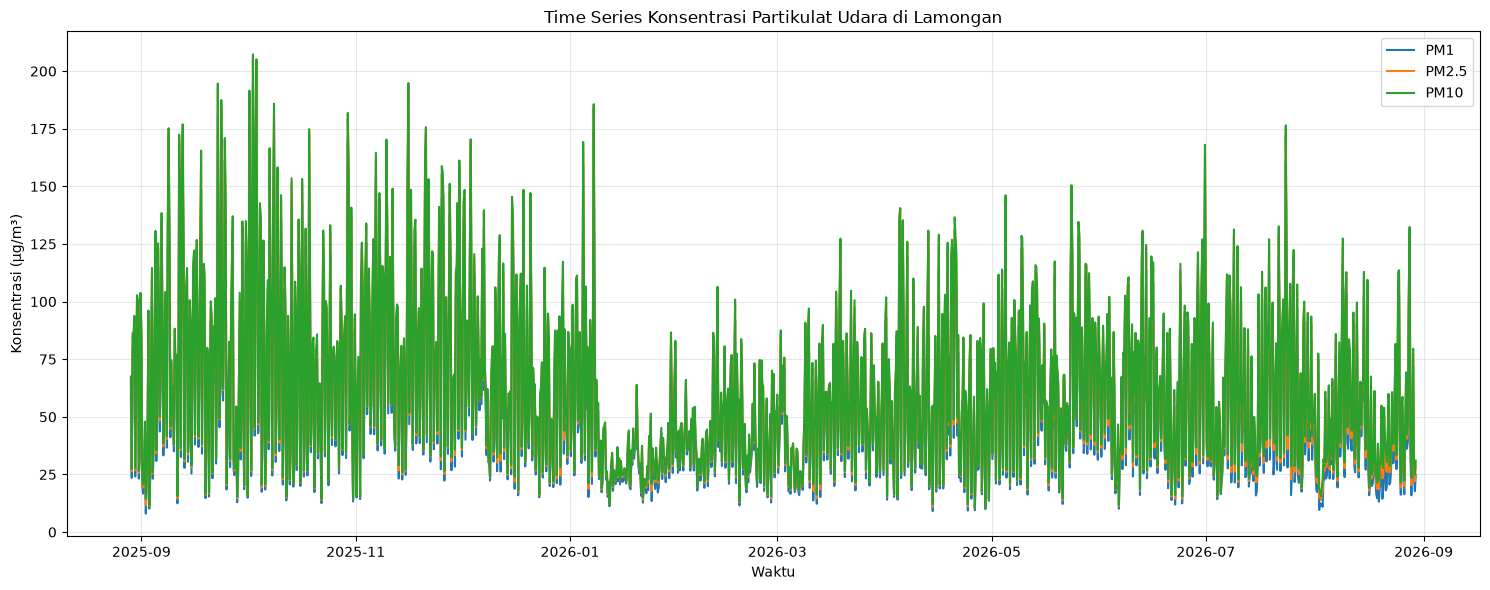

In [8]:
# ============================================================
# [7] TIME SERIES PM
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    df["valid_time"],
    df["pm1_ug_m3"],
    label="PM1"
)

plt.plot(
    df["valid_time"],
    df["pm2p5_ug_m3"],
    label="PM2.5"
)

plt.plot(
    df["valid_time"],
    df["pm10_ug_m3"],
    label="PM10"
)

plt.xlabel("Waktu")
plt.ylabel("Konsentrasi (µg/m³)")
plt.title("Time Series Konsentrasi Partikulat Udara di Lamongan")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Kesimpulan Data Understanding

Berdasarkan eksplorasi awal terhadap dataset kualitas udara di wilayah Lamongan, diperoleh sebanyak 1.464 baris data dengan 6 kolom. Data memiliki periode pengamatan dari 29 Agustus 2025 sampai 29 Agustus 2026.

Variabel utama yang dianalisis adalah konsentrasi partikulat PM1, PM2.5, dan PM10. Ketiga variabel tersebut memiliki satuan µg/m³ setelah dilakukan konversi dari satuan asli kg/m³.

Dataset juga memiliki informasi waktu pengamatan berupa `valid_time` serta koordinat lokasi berupa latitude dan longitude.

Hasil pemeriksaan kualitas data menunjukkan adanya beberapa nilai yang perlu diperiksa lebih lanjut, terutama nilai partikulat negatif dan sejumlah data yang teridentifikasi sebagai outlier. Nilai negatif secara logis tidak merepresentasikan konsentrasi partikulat sebenarnya sehingga perlu ditangani pada tahap data preparation/cleaning.

Eksplorasi statistik deskriptif dan korelasi dilakukan untuk memahami karakteristik serta hubungan antarvariabel partikulat. Selanjutnya, data akan dipersiapkan dan dibersihkan sebelum digunakan untuk analisis dan visualisasi time series.